### Chatbot With Memory

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [2]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)

### 그래프 구성

In [8]:
from typing import TypedDict, Annotated, List # 타입 힌트 도구
from langgraph.graph.message import add_messages # 메세지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages : Annotated[List, add_messages] # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool]
llm_with_tools = llm.bind_tools(tools) # llm에 도구 스펙 파인딩

# State의 messages를 입력 받아, 응답 메세지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages']) # 누적된 메세지 리스트로 LLM 호출
    return {'messages' : [response]} # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

### 메모리 저장소

In [ ]:
# 메모리 기반 체크포인트 저장소 (인메모리)
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver() # 상태 체크포인트를 RAM에 저장하는 객체

memory.blobs

defaultdict(None, {})

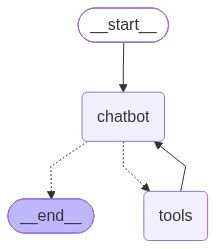

In [6]:
# 직접 구현한 ToolNode와 tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State) # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

builder.add_edge(START, 'chatbot') # START -> chatbot

builder.add_node('chatbot', chatbot)     # chatbot
builder.add_node('tools', tool_node)     # tools

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile(checkpointer=memory) # checkpointer를 포함하여 실행 가능한 그래프로 컴파일
graph

In [9]:
from pprint import pprint
user1_config = {'configurable': {'thread_id': 'user1'}}
state = {'messages': [('human','안녕 나는 min이라고 해! 만나서 반갑다')]}

response = graph.invoke(state, user1_config) # 그래프 비동기 실행
pprint(response)
print("="*30)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='안녕 나는 min이라고 해! 만나서 반갑다', additional_kwargs={}, response_metadata={}, id='59b3b7c4-ea1e-4bbd-941f-d62af7e7c537'),
              HumanMessage(content='안녕 나는 min이라고 해! 만나서 반갑다', additional_kwargs={}, response_metadata={}, id='a79b2423-c193-4d3e-950f-3ccd39a15ede'),
              AIMessage(content='안녕 min! 만나서 반가워요 😊  \n앞으로 편하게 이야기해요. 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1296, 'total_tokens': 1327, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrgiagGkgKHhivMAC1kWMYoshH2e', 'service_tier': 'default', 'fin

In [10]:
state = {'messages': [('human','내 이름이 뭐라고 했지? 기억이 안나네')]}

response = graph.invoke(state, user1_config) # 그래프 비동기 실행
pprint(response)
print("="*30)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='안녕 나는 min이라고 해! 만나서 반갑다', additional_kwargs={}, response_metadata={}, id='59b3b7c4-ea1e-4bbd-941f-d62af7e7c537'),
              HumanMessage(content='안녕 나는 min이라고 해! 만나서 반갑다', additional_kwargs={}, response_metadata={}, id='a79b2423-c193-4d3e-950f-3ccd39a15ede'),
              AIMessage(content='안녕 min! 만나서 반가워요 😊  \n앞으로 편하게 이야기해요. 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1296, 'total_tokens': 1327, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrgiagGkgKHhivMAC1kWMYoshH2e', 'service_tier': 'default', 'fin

In [11]:
user2_config = {'configurable': {'thread_id': 'user2'}}
state = {'messages': [('human','내 이름이 뭐라고 했지? 기억이 안나네')]}

response = graph.invoke(state, user2_config) # 그래프 비동기 실행
pprint(response)
print("="*30)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='내 이름이 뭐라고 했지? 기억이 안나네', additional_kwargs={}, response_metadata={}, id='6d45e351-ba18-4499-a172-43faa50a4fa0'),
              AIMessage(content='지금 대화에서는 아직 당신 이름을 알려주지 않아서 제가 기억하고 있지 못해요.  \n원하시면 이름을 알려주시면 다음부터 그 이름으로 부를게요.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 1281, 'total_tokens': 1326, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrjEkerBdoPpZstw0NlbzwRjzms5', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a06527-5604-74f0-abff-e1e4ed42bb15-0', tool_calls=[], invalid_to

In [17]:
# 체크포인터에 저장된 특정 thread_id의 대화 스냅샷 조회
snapshot = graph.get_state(user1_config)
print(snapshot)
print(snapshot.values['messages'])


StateSnapshot(values={'messages': [HumanMessage(content='안녕 나는 min이라고 해! 만나서 반갑다', additional_kwargs={}, response_metadata={}, id='59b3b7c4-ea1e-4bbd-941f-d62af7e7c537'), HumanMessage(content='안녕 나는 min이라고 해! 만나서 반갑다', additional_kwargs={}, response_metadata={}, id='a79b2423-c193-4d3e-950f-3ccd39a15ede'), AIMessage(content='안녕 min! 만나서 반가워요 😊  \n앞으로 편하게 이야기해요. 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1296, 'total_tokens': 1327, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrgiagGkgKHhivMAC1kWMYoshH2e', 'service_tier': 'default', 'finish_rea

In [26]:
all_snapshot = memory.list({}) # memory에 저장된 전체 스냅샷 리스트 조회

for snapshot in all_snapshot:
    print(f"Thread ID: {snapshot.config['configurable']['thread_id']}") # thread_id
    # print(snapshot.checkpoint['channel_values'])
    if 'messages' in snapshot.checkpoint['channel_values']:
        pprint(snapshot.checkpoint['channel_values']['messages'])
    else:
        print('스냅샷에 저장할 메시지가 없습니다!')
    print()

Thread ID: user1
[HumanMessage(content='안녕 나는 min이라고 해! 만나서 반갑다', additional_kwargs={}, response_metadata={}, id='59b3b7c4-ea1e-4bbd-941f-d62af7e7c537'),
 HumanMessage(content='안녕 나는 min이라고 해! 만나서 반갑다', additional_kwargs={}, response_metadata={}, id='a79b2423-c193-4d3e-950f-3ccd39a15ede'),
 AIMessage(content='안녕 min! 만나서 반가워요 😊  \n앞으로 편하게 이야기해요. 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1296, 'total_tokens': 1327, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJrgiagGkgKHhivMAC1kWMYoshH2e', 'service_tier': 'default', 'finish_reason': 'stop', '

memory상에 대화간 입력했던 내용들이 스냅샷으로 저장되고,  
이 스냅샷에서 최종 대화내용 중 실제 대화만 꺼내어 영속적인 DB에 저장하여 유지한다.